# A Model for Newton's Law of Cooling

## Model Description

According to Newton's Law of Cooling, the rate of change of the temperature of a body is proportional to the difference in the ambient temperature and the current temperature of the body. So, if $T(t)$ is the temperature of the body at time $t$, $T_\textrm{amb}$ is the ambient temperature, and $r>0$ is a constant of proportionality (with units of one over time), then

$$
\frac{\mathrm{d}}{\mathrm{d}t}T(t) = -r \left( T(t) - T_\mathrm{amb} \right)
$$

In order to solve an initial value problem for the Newton's Law of Cooling model, one needs to provide the values of three parameters: the rate constant, $r$; the ambient temperature, $T_\textrm{amb}$; and the initial temperature of the body, $T_0$, such that $T(0) = T_0$.

## MCSim Model Specification

We used the [GNU MCSim](https://www.gnu.org/software/mcsim/) model specification language to implement the Newton's Law of Cooling model. The complete MCSim model specification file for this model, `newt_cool.model`, can be found in the `extdata` subdirectory of the **MCSimMod** package installation directory.

In the model specification file, the text symbol `T` is used to represent the state variable $T$, and the text symbols `r`, `Tamb`, and `T0` are used to represent the parameters $r$, $T_\textrm{amb}$, and $T_0$, respectively.

## Building the Model

First, we load the **MCSimMod** package as follows.

In [1]:
%load_ext autoreload
%autoreload 2

from pymcsimmod import create_model

Using the following commands, we create a `newt_cool` model object (i.e., an instance of the `ScipyModel` class) using the model specification file `newt_cool.model` that is included in the **PyMCSimMod** package.

In [2]:
import importlib.resources
with importlib.resources.path('pymcsimmod.data', 'newt_cool.model') as filename:
    newt_mod = create_model(filename, backend="scipy")

## Predicting the Temperature of a Cup of Tea

Suppose we want to predict the temperature of a cup of tea that has an initial temperature of 95&deg;C when the ambient air temperature is 22&deg;C and the rate constant parameter has a value of 0.7 (i.e., $T_0 = 95$, $T_\textrm{amb} = 22$, and $r = 0.7$). We can change the parameter values from their default values (which are given in the model specification file) to the values we wish to use for simulation of this scenario. 

In [3]:
# Change the values of the model parameters from their default values.
newt_mod.update_constants(T0 = 95, Tamb = 22, r = 0.7)

print(newt_mod.parameters)
print(newt_mod.Y0)

{'T0': 95, 'r': 0.7, 'Tamb': 22}
{'T': 95}


Note that executing the command `newt_mod.update_constants(T0=95, Tamb=22, r=0.7)` updates the parameter values (replacing the default values that were provided in the model specification file) and automatically updates any parameters used to define the initial value of the state variable `T` using the updated value of the parameter `T0`.

Finally, we can perform a simulation that provides results for the desired output times (i.e., $t = 0, 0.1, 0.2, \ldots, 5.0$) using the following commands.

In [4]:
import numpy as np

# Define output times for simulation.
times = np.arange(start = 0, stop = 5, step = 0.1)

# Run simulation.
results = newt_mod.run_model(times)

## Examining the Results

The final command shown above, `results = newt_mod.run_model(times)`,  performs a model simulation and stores the simulation results in a `ComputedModel` object called `results`. The simulated results can be accessed from this object using the `dataframe` property as `out = results.dataframe`. In `out`, there is one row for each output time, and one column for the time and each state variable (and each output variable when such variables are included in the model). The first five rows of this data structure are shown below. Note that the independent variable, which is $t$ in the case of the Newton's Law of Cooling model, is always labeled "time" in the output data structure.

In [5]:
out = results.dataframe
display(out.head())

,time,T
0,0.0,95.000000
1,0.1,90.106582
2,0.2,85.514963
3,0.3,81.220904
4,0.4,77.213209


We can examine the parameter values and initial conditions that were used for this simulation using the following commands.

In [6]:
print(newt_mod.parameters)
print(newt_mod.Y0)

{'T0': 95, 'r': 0.7, 'Tamb': 22}
{'T': 95}


Finally, we can create a visual representation of the simulation results. For example, we can plot the temperature vs. time using the following commands.

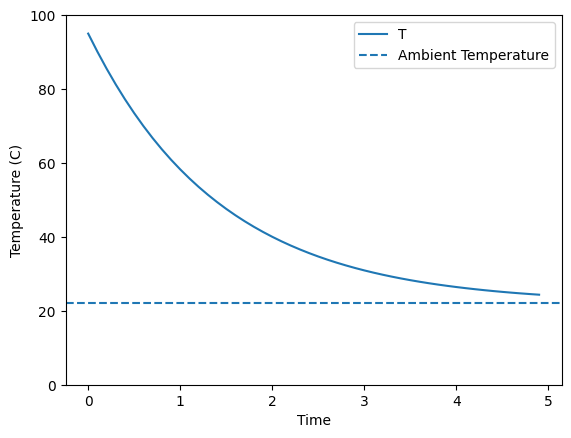

In [7]:
ax = results.plot_results(variables=['T'], xlabel='Time', ylabel='Temperature (C)')
ax.axhline(y=newt_mod.parameters['Tamb'], linestyle='--', label='Ambient Temperature')
ax.set_ylim([0, 100])
ax.legend()